In [ ]:
# Import Libraries
!pip install emoji
!pip install tqdm
import pandas as pd
import numpy as np
import re
import string
import emoji

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from collections import Counter

import seaborn as sns
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords
from nltk.stem.isri import ISRIStemmer

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
# Load files
neg_train = pd.read_csv("train_Arabic_tweets_negative_20190413.tsv", sep='\t', header=None)
pos_train = pd.read_csv("train_Arabic_tweets_positive_20190413.tsv", sep='\t', header=None)
pos_test = pd.read_csv("test_Arabic_tweets_positive_20190413.tsv", sep='\t', header=None)
neg_test = pd.read_csv("test_Arabic_tweets_negative_20190413.tsv", sep='\t', header=None)



In [ ]:
train_df = (
    pd.concat([pos_train, neg_train], ignore_index=True)
      .sample(frac=1, random_state=42)
      .reset_index(drop=True)
)

test_df = (
    pd.concat([pos_test, neg_test], ignore_index=True)
      .sample(frac=1, random_state=42)
      .reset_index(drop=True)
)

In [ ]:
for df in [train_df, test_df]:
    df.columns = ['label', 'tweet']

In [ ]:
df.shape

(11520, 2)

<Axes: xlabel='label', ylabel='count'>

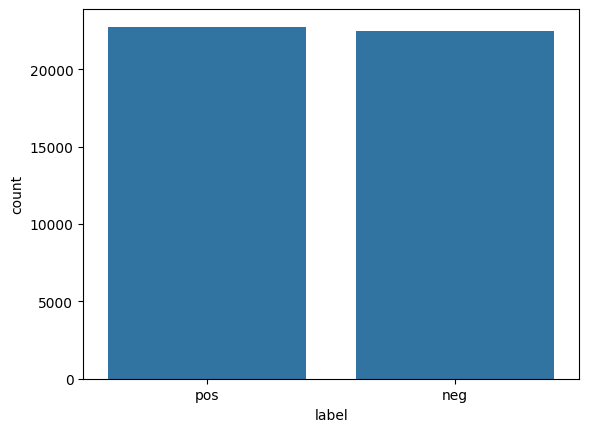

In [ ]:
sns.countplot(data=train_df,x='label')

In [ ]:

emoji_pattern = re.compile(
    "["
    "\U0001F600-\U0001F64F"  # emotions
    "\U0001F300-\U0001F5FF"  # symbols & pictographs
    "\U0001F680-\U0001F6FF"  # transport & map
    "\U0001F1E0-\U0001F1FF"  # flags
    "\U00002700-\U000027BF"
    "\U000024C2-\U0001F251"
    "]+",
    flags=re.UNICODE
)

def extract_emojis(text):
    return emoji_pattern.findall(str(text))

In [ ]:
train_df["emojies"] = train_df["tweet"].apply(extract_emojis)

In [ ]:
train_df.head(5)

,label,tweet,emojies
0,pos,مقال يدور حول الحمى يوشك ان يقع فيه 😊,[😊]
1,pos,تيشرت القائد 💙,[💙]
2,neg,وكل السعوديه بدو ..حتى الحاضره منهم من اصل بدو...,[😩]
3,neg,المونافري طلع برهوش .. سدينا 😤,[😤]
4,neg,منو خر بيتهم مثلنا 😩,[😩]


In [ ]:
from tqdm.auto import tqdm
tqdm.pandas()

exclude=[string.punctuation]
exclude.append('﴾')
exclude.append('﴿')
exclude.append('؟')
def remove_punc(text):
  for char in exclude:
    text=text.replace(char,'')
  return text

train_df['tweet']=train_df['tweet'].progress_apply(lambda x : remove_punc(x))
test_df['tweet']=test_df['tweet'].progress_apply(lambda x : remove_punc(x))

  0%|          | 0/45275 [00:00<?, ?it/s]

  0%|          | 0/11520 [00:00<?, ?it/s]

In [ ]:
train_df.head(5)

,label,tweet,emojies
0,pos,مقال يدور حول الحمى يوشك ان يقع فيه 😊,[😊]
1,pos,تيشرت القائد 💙,[💙]
2,neg,وكل السعوديه بدو ..حتى الحاضره منهم من اصل بدو...,[😩]
3,neg,المونافري طلع برهوش .. سدينا 😤,[😤]
4,neg,منو خر بيتهم مثلنا 😩,[😩]


In [ ]:
def remove_digits(text):
  text=re.sub('\w*\d\w*','',text)
  return text

train_df['tweet']=train_df['tweet'].progress_apply(lambda x : remove_digits(x))
test_df['tweet']=test_df['tweet'].progress_apply(lambda x : remove_digits(x))

<>:2: SyntaxWarning: invalid escape sequence '\w'
<>:2: SyntaxWarning: invalid escape sequence '\w'
/tmp/ipykernel_1581/1744823745.py:2: SyntaxWarning: invalid escape sequence '\w'
  text=re.sub('\w*\d\w*','',text)


  0%|          | 0/45275 [00:00<?, ?it/s]

  0%|          | 0/11520 [00:00<?, ?it/s]

In [ ]:
stopwords=stopwords.words('english')
stopwords

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [ ]:
def remove_stopwords(text):
  filtered_words=[word for word in text.split() if word not in stopwords]
  return ' '.join(filtered_words)

train_df['tweet']=train_df['tweet'].progress_apply(lambda x : remove_stopwords(x))
test_df['tweet']=test_df['tweet'].progress_apply(lambda x : remove_stopwords(x))


  0%|          | 0/45275 [00:00<?, ?it/s]

  0%|          | 0/11520 [00:00<?, ?it/s]

In [ ]:
arabic_StopWords = nltk.corpus.stopwords.words("arabic")
arabic_StopWords

['إذ',
 'إذا',
 'إذما',
 'إذن',
 'أف',
 'أقل',
 'أكثر',
 'ألا',
 'إلا',
 'التي',
 'الذي',
 'الذين',
 'اللاتي',
 'اللائي',
 'اللتان',
 'اللتيا',
 'اللتين',
 'اللذان',
 'اللذين',
 'اللواتي',
 'إلى',
 'إليك',
 'إليكم',
 'إليكما',
 'إليكن',
 'أم',
 'أما',
 'أما',
 'إما',
 'أن',
 'إن',
 'إنا',
 'أنا',
 'أنت',
 'أنتم',
 'أنتما',
 'أنتن',
 'إنما',
 'إنه',
 'أنى',
 'أنى',
 'آه',
 'آها',
 'أو',
 'أولاء',
 'أولئك',
 'أوه',
 'آي',
 'أي',
 'أيها',
 'إي',
 'أين',
 'أين',
 'أينما',
 'إيه',
 'بخ',
 'بس',
 'بعد',
 'بعض',
 'بك',
 'بكم',
 'بكم',
 'بكما',
 'بكن',
 'بل',
 'بلى',
 'بما',
 'بماذا',
 'بمن',
 'بنا',
 'به',
 'بها',
 'بهم',
 'بهما',
 'بهن',
 'بي',
 'بين',
 'بيد',
 'تلك',
 'تلكم',
 'تلكما',
 'ته',
 'تي',
 'تين',
 'تينك',
 'ثم',
 'ثمة',
 'حاشا',
 'حبذا',
 'حتى',
 'حيث',
 'حيثما',
 'حين',
 'خلا',
 'دون',
 'ذا',
 'ذات',
 'ذاك',
 'ذان',
 'ذانك',
 'ذلك',
 'ذلكم',
 'ذلكما',
 'ذلكن',
 'ذه',
 'ذو',
 'ذوا',
 'ذواتا',
 'ذواتي',
 'ذي',
 'ذين',
 'ذينك',
 'ريث',
 'سوف',
 'سوى',
 'شتان',
 'عدا',
 'عسى',
 'عل'

In [ ]:
def remove_arabic_stopwords(text):
  filtered_words=[word for word in text.split() if word not in arabic_StopWords]
  return ' '.join(filtered_words)

train_df['tweet']=train_df['tweet'].progress_apply(lambda x : remove_arabic_stopwords(x))
test_df['tweet']=test_df['tweet'].progress_apply(lambda x : remove_arabic_stopwords(x))


  0%|          | 0/45275 [00:00<?, ?it/s]

  0%|          | 0/11520 [00:00<?, ?it/s]

In [ ]:
train_df.head(5)

,label,tweet,emojies
0,pos,مقال يدور حول الحمى يوشك ان يقع 😊,[😊]
1,pos,تيشرت القائد 💙,[💙]
2,neg,وكل السعوديه بدو ..حتى الحاضره منهم اصل بدوي 😩...,[😩]
3,neg,المونافري طلع برهوش .. سدينا 😤,[😤]
4,neg,منو خر بيتهم مثلنا 😩,[😩]


In [ ]:
!pip install pyarabic
from pyarabic.araby import strip_tashkeel

def clean_arabic_text(text):
    # 1. Remove diacritics (التشكيل)
    text = strip_tashkeel(text)

    # 2. Remove Arabic + English punctuation
    arabic_punct = "،؛؟ـ«»…"
    all_punct = string.punctuation + arabic_punct
    text = text.translate(str.maketrans('', '', all_punct))

    # 3. Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

train_df['tweet'] = train_df['tweet'].progress_apply(clean_arabic_text)
test_df['tweet'] = test_df['tweet'].progress_apply(clean_arabic_text)

  0%|          | 0/45275 [00:00<?, ?it/s]

  0%|          | 0/11520 [00:00<?, ?it/s]

In [ ]:
def normalize_arabic(text):
    text = re.sub("[إأآا]", "ا", text)
    text = re.sub("ى", "ي", text)
    text = re.sub("ؤ", "و", text)
    text = re.sub("ئ", "ي", text)
    return text

train_df['tweet']=train_df['tweet'].progress_apply(lambda x : normalize_arabic(x))
test_df['tweet']=test_df['tweet'].progress_apply(lambda x : normalize_arabic(x))

  0%|          | 0/45275 [00:00<?, ?it/s]

  0%|          | 0/11520 [00:00<?, ?it/s]

In [ ]:
def repeated_letter(text):
  text = re.sub(r'(.)\1{2,}', r'\1', text)
  return text
train_df['tweet']=train_df['tweet'].progress_apply(lambda x : repeated_letter(x))
test_df['tweet']=test_df['tweet'].progress_apply(lambda x : repeated_letter(x))

  0%|          | 0/45275 [00:00<?, ?it/s]

  0%|          | 0/11520 [00:00<?, ?it/s]

In [ ]:
def arabic_english(text):
  text = re.sub(r'[^\u0600-\u06FFa-zA-Z\s]', '', text)
  return text

train_df['tweet']=train_df['tweet'].progress_apply(lambda x : arabic_english(x))
test_df['tweet']=test_df['tweet'].progress_apply(lambda x : arabic_english(x))


  0%|          | 0/45275 [00:00<?, ?it/s]

  0%|          | 0/11520 [00:00<?, ?it/s]

In [ ]:
def remove_spaces(text):
  text = re.sub(r'\s+', ' ', text).strip()
  return text

train_df['tweet']=train_df['tweet'].progress_apply(lambda x : remove_spaces(x))
test_df['tweet']=test_df['tweet'].progress_apply(lambda x : remove_spaces(x))


  0%|          | 0/45275 [00:00<?, ?it/s]

  0%|          | 0/11520 [00:00<?, ?it/s]

##RNN Implementation

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

In [ ]:
vocab_size = 20000
tokenizer = Tokenizer(
        num_words=vocab_size,
        oov_token="<OOV>"
)
tokenizer.fit_on_texts(train_df['tweet'])

In [ ]:
train_df['text_sequences'] = tokenizer.texts_to_sequences(train_df['tweet'])
test_df['text_sequences'] = tokenizer.texts_to_sequences(test_df['tweet'])

In [ ]:
for word, index in tokenizer.word_index.items():
    print(word, index)
    if index == 10:
        break

<OOV> 1
الله 2
اللهم 3
اللي 4
انا 5
والله 6
الهلال 7
ان 8
الخير 9
الي 10


In [ ]:
vocab_size = len(tokenizer.word_index)

In [ ]:
train_df.head(5)

,label,tweet,emojies,text_sequences
0,pos,مقال يدور حول الحمي يوشك ان يقع,[😊],"[3295, 571, 281, 1, 1, 8, 3888]"
1,pos,تيشرت القايد,[💙],"[16469, 3681]"
2,neg,وكل السعوديه بدو حتي الحاضره منهم اصل بدوي انا...,[😩],"[240, 1476, 4403, 552, 1, 530, 2712, 16470, 5,..."
3,neg,المونافري طلع برهوش سدينا,[😤],"[1, 424, 1, 1]"
4,neg,منو خر بيتهم مثلنا,[😩],"[1292, 1, 16472, 16473]"


In [ ]:
# Compute sequence lengths
sequence_lengths = [len(seq) for seq in train_df['text_sequences']]

# Count frequencies of each length
length_counts = Counter(sequence_lengths)

# Prepare data for plotting
lengths = list(length_counts.keys())
counts = list(length_counts.values())

In [ ]:
length_counts.most_common(5)

[(3, 3730), (2, 3643), (4, 3430), (5, 2982), (6, 2618)]

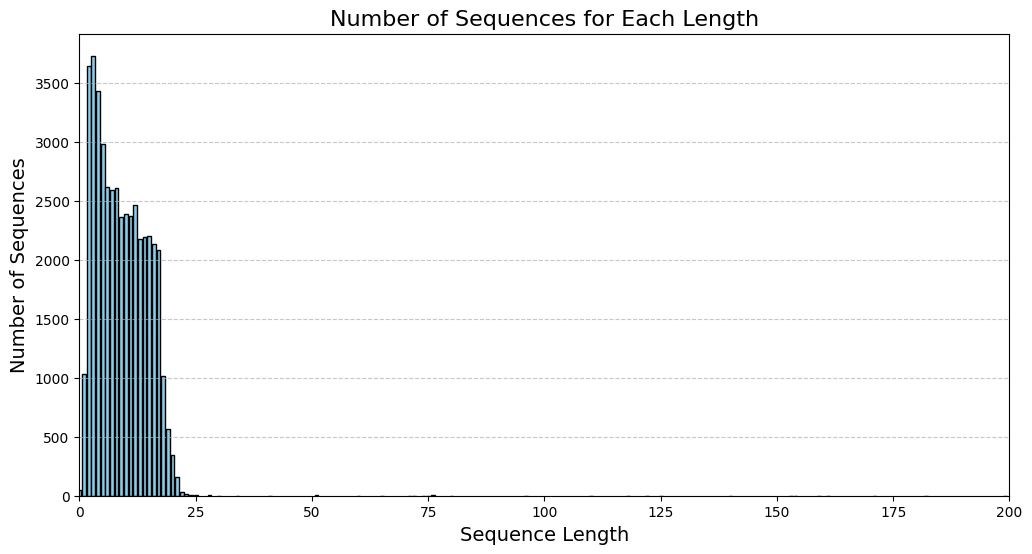

In [ ]:
plt.figure(figsize=(12, 6))
plt.bar(lengths, counts, color='skyblue', edgecolor='black')

plt.title('Number of Sequences for Each Length', fontsize=16)
plt.xlabel('Sequence Length', fontsize=14)
plt.ylabel('Number of Sequences', fontsize=14)

plt.xlim(0, 200)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
input_shape = 25

In [ ]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(train_df['tweet'])

In [ ]:
X_train_seq = tokenizer.texts_to_sequences(train_df['tweet'])
X_test_seq = tokenizer.texts_to_sequences(test_df['tweet'])

In [ ]:
X_train = pad_sequences(X_train_seq, maxlen=input_shape, padding='post')
X_test = pad_sequences(X_test_seq, maxlen=input_shape, padding='post')

In [ ]:
LB = LabelEncoder()
y_train = LB.fit_transform(train_df['label'])
y_test = LB.transform(test_df['label'])

In [ ]:
y_train = np.array(y_train, dtype="int32")
y_test = np.array(y_test, dtype="int32")

X_train = np.array(X_train, dtype="int32")
X_test = np.array(X_test, dtype="int32")

In [ ]:

model = tf.keras.models.Sequential([

    tf.keras.layers.Input(shape=(input_shape,)),

    tf.keras.layers.Embedding(
        input_dim=vocab_size + 1,
        output_dim=128
    ),

    tf.keras.layers.SimpleRNN(64),

    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(1, activation="sigmoid")
])

In [ ]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
print(model.summary())

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 25, 128)        │     8,418,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_4 (SimpleRNN)        │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,430,593 (32.16 MB)

 Trainable params: 8,430,593 (32.16 MB)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=64,
    validation_split=0.2,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/100
566/566 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - accuracy: 0.6657 - loss: 0.5684
Epoch 1: val_accuracy improved from None to 0.76499, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
566/566 ━━━━━━━━━━━━━━━━━━━━ 81s 139ms/step - accuracy: 0.7187 - loss: 0.5088 - val_accuracy: 0.7650 - val_loss: 0.4363
Epoch 2/100
566/566 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.9454 - loss: 0.1474
Epoch 2: val_accuracy did not improve from 0.76499
566/566 ━━━━━━━━━━━━━━━━━━━━ 71s 120ms/step - accuracy: 0.9401 - loss: 0.1535 - val_accuracy: 0.7533 - val_loss: 0.5627
Epoch 3/100
566/566 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - accuracy: 0.9734 - loss: 0.0665
Epoch 3: val_accuracy did not improve from 0.76499
566/566 ━━━━━━━━━━━━━━━━━━━━ 84s 123ms/step - accuracy: 0.9715 - loss: 0.0719 - val_accuracy: 0.7465 - val_loss: 0.5833
Epoch 4/100
566/566 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.9792 - loss: 0.0504
Epoch 4: val_accuracy did not improve from 0

In [ ]:
best_model = tf.keras.models.load_model("best_model.keras")

In [ ]:

y_pred_prob = model.predict(X_test)

y_pred = (y_pred_prob > 0.4).astype(int).flatten()

print(
    classification_report(
        y_test,
        y_pred,
        target_names=LB.classes_
    )
)

360/360 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
              precision    recall  f1-score   support

         neg       0.83      0.62      0.71      5768
         pos       0.70      0.87      0.77      5752

    accuracy                           0.75     11520
   macro avg       0.76      0.75      0.74     11520
weighted avg       0.76      0.75      0.74     11520



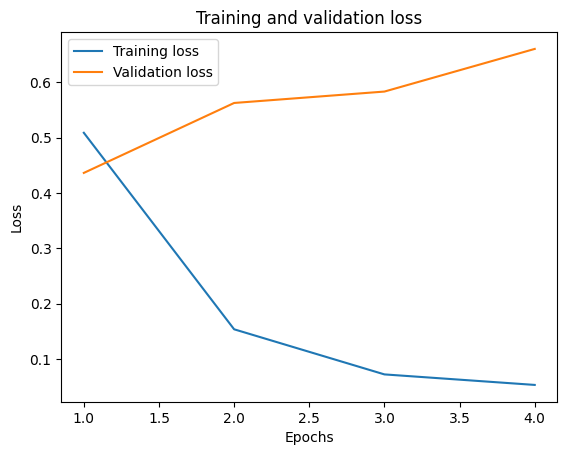

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.plot(epochs, loss, label='Training loss')
plt.plot(epochs, val_loss, label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

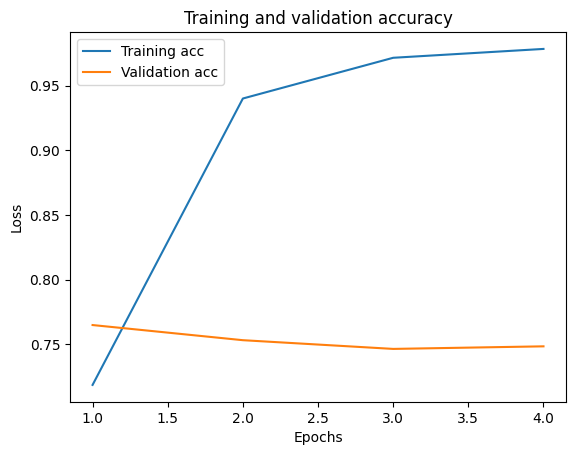

In [ ]:

plt.clf()
acc_values = history.history['accuracy']
val_acc_values = history.history['val_accuracy']

plt.plot(epochs, acc, label='Training acc')
plt.plot(epochs, val_acc, label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [ ]:
print("Test Accuracy:", accuracy_score(y_test, y_pred))

Test Accuracy: 0.7452256944444444


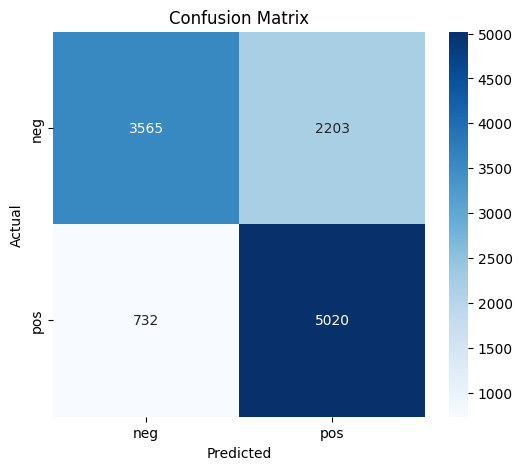

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=LB.classes_,
    yticklabels=LB.classes_
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
# Test new Sentences
new_text = [
    "الخدمة ممتازة جدا جدا",
    "سيئة للغاية ولن أكرر التجربة مرة أخرى",
    "التجربة كانت عادية"
]

seq = tokenizer.texts_to_sequences(new_text)
padded = pad_sequences(seq, maxlen=input_shape, padding='post')

pred = model.predict(padded)
pred_classes = (pred > 0.5).astype(int).flatten()

results = LB.inverse_transform(pred_classes)

for text, label in zip(new_text, results):
    print(text, " ---> ", label)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
الخدمة ممتازة جدا جدا  --->  pos
سيئة للغاية ولن أكرر التجربة مرة أخرى  --->  neg
التجربة كانت عادية  --->  pos
